# Can we algorithmically identify single or sequential perturbations that optimally transition a disease-associated expression state toward a desired therapeutic attract

# 01 – LINCS Setup and Metadata Overview (MCF7 / 24h / trt_cp)

This notebook prepares the LINCS L1000 dataset for downstream analysis.

**Goals:**

1. Set up project paths (`data/raw`, `data/processed`).
2. Verify the presence of required LINCS files (GCTX + metadata).
3. Load and summarise key metadata tables:
   - `sig_info` (signatures)
   - `cell_info` (cell lines)
   - `pert_info` (perturbations)
   - `gene_info` (genes)
4. Define a **working subset**:
   - Cell line: **MCF7**
   - Perturbation type: **trt_cp** (small molecules)
   - Timepoint: **24 h**
5. Save the filtered `sig_info` subset for use in notebook `02_consensus_building.ipynb`.

No expression matrix is loaded here – that happens in 02.


# 01 – LINCS Setup and Data Overview

This notebook:

1. Checks the analysis environment (Python + packages).
2. Loads a LINCS L1000 GCT/GCTX file.
3. Summarises expression and metadata (cell lines, perturbations, time points).
4. Saves a small subset for later state-space and perturbation trajectory analysis.

This is the entry point for the **LINCS State-Space Navigator** project.


# 1. Imports & paths

In [2]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -----------------------------------------------------------------
# Project root and data directories
# -----------------------------------------------------------------
PROJECT_ROOT = Path(
    r"C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator"
).resolve()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_RAW:", DATA_RAW)
print("DATA_PROCESSED:", DATA_PROCESSED)

DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print("\nPackage versions:")
print("pandas:", pd.__version__)
print("numpy :", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)


PROJECT_ROOT: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator
DATA_RAW: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator\data\raw
DATA_PROCESSED: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator\data\processed

Package versions:
pandas: 2.2.3
numpy : 2.1.3
matplotlib: 3.10.0
seaborn: 0.13.2


# 2. Check required raw files exist

In [5]:
# Expected LINCS files (GSE70138)
required_files = {
    "gctx_level5": "GSE70138_Broad_LINCS_Level5_COMPZ_n118050x12328_2017-03-06.gctx.gz",
    "sig_info":    "GSE70138_Broad_LINCS_sig_info_2017-03-06.txt.gz",
    "gene_info":   "GSE70138_Broad_LINCS_gene_info_2017-03-06.txt.gz",
    "cell_info":   "GSE70138_Broad_LINCS_cell_info_2017-04-28.txt.gz",
    "pert_info":   "GSE70138_Broad_LINCS_pert_info.txt.gz",
}

paths = {k: DATA_RAW / v for k, v in required_files.items()}

print("Checking raw files in:", DATA_RAW, "\n")
for key, path in paths.items():
    print(f"{key:12s} -> {'FOUND' if path.exists() else 'MISSING'}  ({path.name})")

missing = [k for k, p in paths.items() if not p.exists()]
if missing:
    print("Missing files:", missing)
    print("Please download them to data/raw before proceeding.")
else:
    print("All required raw files found.")


Checking raw files in: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator\data\raw 

gctx_level5  -> FOUND  (GSE70138_Broad_LINCS_Level5_COMPZ_n118050x12328_2017-03-06.gctx.gz)
sig_info     -> FOUND  (GSE70138_Broad_LINCS_sig_info_2017-03-06.txt.gz)
gene_info    -> FOUND  (GSE70138_Broad_LINCS_gene_info_2017-03-06.txt.gz)
cell_info    -> FOUND  (GSE70138_Broad_LINCS_cell_info_2017-04-28.txt.gz)
pert_info    -> FOUND  (GSE70138_Broad_LINCS_pert_info.txt.gz)
All required raw files found.


# 3. Load core metadata tables

In [7]:
# Load sig_info
sig_info = pd.read_csv(paths["sig_info"], sep="\t")
print("sig_info shape:", sig_info.shape)
display(sig_info.head())

# Load cell_info
cell_info = pd.read_csv(paths["cell_info"], sep="\t")
print("\ncell_info shape:", cell_info.shape)
display(cell_info.head())

# Load pert_info
pert_info = pd.read_csv(paths["pert_info"], sep="\t")
print("\npert_info shape:", pert_info.shape)
display(pert_info.head())

# Load gene_info
gene_info = pd.read_csv(paths["gene_info"], sep="\t")
print("\ngene_info shape:", gene_info.shape)
display(gene_info.head())


sig_info shape: (118050, 8)


,sig_id,pert_id,pert_iname,pert_type,cell_id,pert_idose,pert_itime,distil_id
0,LJP005_A375_24H:A03,DMSO,DMSO,ctl_vehicle,A375,-666,24 h,LJP005_A375_24H_X1_B19:A03|LJP005_A375_24H_X2_...
1,LJP005_A375_24H:A04,DMSO,DMSO,ctl_vehicle,A375,-666,24 h,LJP005_A375_24H_X1_B19:A04|LJP005_A375_24H_X2_...
2,LJP005_A375_24H:A05,DMSO,DMSO,ctl_vehicle,A375,-666,24 h,LJP005_A375_24H_X1_B19:A05|LJP005_A375_24H_X2_...
3,LJP005_A375_24H:A06,DMSO,DMSO,ctl_vehicle,A375,-666,24 h,LJP005_A375_24H_X1_B19:A06|LJP005_A375_24H_X2_...
4,LJP005_A375_24H:A07,BRD-K76908866,CP-724714,trt_cp,A375,10.0 um,24 h,LJP005_A375_24H_X1_B19:A07|LJP005_A375_24H_X2_...



cell_info shape: (98, 14)


,cell_id,cell_type,base_cell_id,precursor_cell_id,modification,sample_type,primary_site,subtype,original_growth_pattern,provider_catalog_id,original_source_vendor,donor_age,donor_sex,donor_ethnicity
0,A375,cell line,A375,-666,-666,tumor,skin,malignant melanoma,adherent,CRL-1619,ATCC,54,F,-666
1,A375.311,cell line,A375,A375,genetically modified to stably express Cas9 pr...,tumor,skin,malignant melanoma,adherent,CRL-1619,ATCC,54,F,-666
2,A549,cell line,A549,-666,-666,tumor,lung,non small cell lung cancer| carcinoma,adherent,CCL-185,ATCC,58,M,Caucasian
3,A549.311,cell line,A549,A549,genetically modified to stably express Cas9 p...,tumor,lung,non small cell lung cancer| carcinoma,adherent,CCL-185,ATCC,58,M,Caucasian
4,A673,cell line,A673,-666,-666,tumor,bone,ewing's sarcoma,adherent,CRL-1598,ATCC,-666,F,-666



pert_info shape: (2170, 5)


,pert_id,canonical_smiles,inchi_key,pert_iname,pert_type
0,BRD-K70792160,CCN(CC)CCCCN1c2ccccc2Oc2ccc(Cl)cc12,GYBXAGDWMCJZJK-UHFFFAOYSA-N,10-DEBC,trt_cp
1,BRD-K68552125,CCCCCCCCCCCCCC(=O)O[C@@H]1[C@@H](C)[C@]2(O)[C@...,PHEDXBVPIONUQT-RGYGYFBISA-N,phorbol-myristate-acetate,trt_cp
2,BRD-K92301463,CCCCC(C)(C)[C@H](O)\C=C\[C@H]1[C@H](O)CC(=O)[C...,QAOBBBBDJSWHMU-WMBBNPMCSA-N,"16,16-dimethylprostaglandin-e2",trt_cp
3,BRD-A29731977,CCCCCC(=O)O[C@@]1(CCC2C3CCC4=CC(=O)CC[C@]4(C)C...,DOMWKUIIPQCAJU-JKPPDDDBSA-N,17-hydroxyprogesterone-caproate,trt_cp
4,BRD-K07954936,OC(=O)CCCC[C@@H]1SC[C@@H]2NC(=N)N[C@H]12,WWVANQJRLPIHNS-ZKWXMUAHSA-N,2-iminobiotin,trt_cp



gene_info shape: (12328, 5)


,pr_gene_id,pr_gene_symbol,pr_gene_title,pr_is_lm,pr_is_bing
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
2,2978,GUCA1A,guanylate cyclase activator 1A,0,0
3,2049,EPHB3,EPH receptor B3,0,1
4,2101,ESRRA,estrogen related receptor alpha,0,1


# 4. Basic metadata summaries

In [8]:
print("Unique cell lines in sig_info:", sig_info["cell_id"].nunique())
print(sig_info["cell_id"].value_counts().head(20))

print("\nPerturbation types:")
print(sig_info["pert_type"].value_counts())

print("\nTimepoint distribution (pert_itime):")
print(sig_info["pert_itime"].value_counts().head(20))


Unique cell lines in sig_info: 41
cell_id
MCF7        13476
A375        12740
PC3         12719
HT29        12529
HA1E        12481
YAPC        10621
HELA        10617
A549         2082
HCC515       1900
HEPG2        1899
HME1         1895
BT20         1520
HS578T       1516
MDAMB231     1515
MCF10A       1514
SKBR3        1514
NPC.TAK      1283
NPC          1198
ASC          1136
ASC.C        1135
Name: count, dtype: int64

Perturbation types:
pert_type
trt_cp         107404
ctl_vehicle      6467
trt_xpr          3882
ctl_vector        209
ctl_untrt          88
Name: count, dtype: int64

Timepoint distribution (pert_itime):
pert_itime
24 h    107440
3 h       5313
96 h      4179
6 h       1118
Name: count, dtype: int64


# 5. We are Focussing on MCF7 / 24h / trt_cp

In [9]:
TARGET_CELL = "MCF7"
TARGET_TYPE = "trt_cp"
TARGET_TIME = "24 h"

subset_meta = sig_info[
    (sig_info["cell_id"] == TARGET_CELL) &
    (sig_info["pert_type"] == TARGET_TYPE) &
    (sig_info["pert_itime"] == TARGET_TIME)
].copy()

print(f"Filtered signatures for {TARGET_CELL}, {TARGET_TYPE}, {TARGET_TIME}:")
print("subset_meta shape:", subset_meta.shape)
display(subset_meta[["sig_id", "pert_iname", "pert_idose", "pert_itime"]].head(10))


Filtered signatures for MCF7, trt_cp, 24 h:
subset_meta shape: (11850, 8)


,sig_id,pert_iname,pert_idose,pert_itime
4557,LJP005_MCF7_24H:A07,CP-724714,10.0 um,24 h
4558,LJP005_MCF7_24H:A08,CP-724714,3.33 um,24 h
4559,LJP005_MCF7_24H:A09,CP-724714,1.11 um,24 h
4560,LJP005_MCF7_24H:A10,CP-724714,0.37 um,24 h
4561,LJP005_MCF7_24H:A11,CP-724714,0.12 um,24 h
4562,LJP005_MCF7_24H:A12,CP-724714,0.04 um,24 h
4563,LJP005_MCF7_24H:A13,neratinib,10.0 um,24 h
4564,LJP005_MCF7_24H:A14,neratinib,3.33 um,24 h
4565,LJP005_MCF7_24H:A15,neratinib,1.11 um,24 h
4566,LJP005_MCF7_24H:A16,neratinib,0.37 um,24 h


# 6. How many perturbagens / doses do we have?

In [12]:
print("Number of unique sig_id:", subset_meta["sig_id"].nunique())
print("Number of unique perturbagens (pert_iname):", subset_meta["pert_iname"].nunique())

print("\nTop 20 perturbagens by #signatures:")
display(subset_meta["pert_iname"].value_counts().head(20))

print("\nDose distribution (pert_idose) for MCF7 24h trt_cp:")
display(subset_meta["pert_idose"].value_counts().head(20))


Number of unique sig_id: 11850
Number of unique perturbagens (pert_iname): 1732

Top 20 perturbagens by #signatures:


pert_iname
bortezomib      342
MG-132          336
PD-0325901       36
dasatinib        36
GSK-1059615      36
CGP-60474        30
mitoxantrone     21
veliparib        18
AZD-7762         18
saracatinib      18
BI-2536          18
olaparib         18
sirolimus        15
GDC-0068         12
SGX523           12
AZ-628           12
dinaciclib       12
PF-04217903      12
AZD-4547         12
TAK-715          12
Name: count, dtype: int64


Dose distribution (pert_idose) for MCF7 24h trt_cp:


pert_idose
10.0 um    1853
0.04 um    1853
0.37 um    1846
1.11 um    1844
3.33 um    1844
0.12 um    1844
20.0 um     672
0.01 um       6
0.02 um       5
1.0 um        5
0.0 um        5
0.11 um       5
0.33 um       5
0.05 um       3
0.07 um       2
0.14 um       2
1.12 um       2
0.06 um       2
0.03 um       2
0.22 um       1
Name: count, dtype: int64

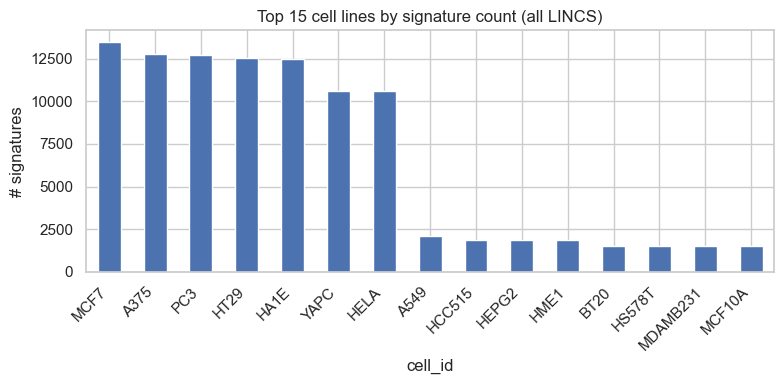

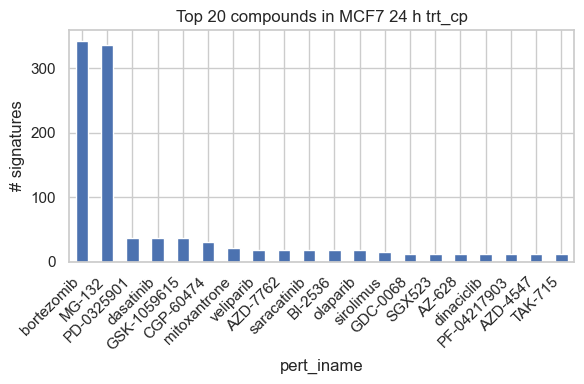

In [13]:
plt.figure(figsize=(8,4))
sig_info["cell_id"].value_counts().head(15).plot(kind="bar")
plt.ylabel("# signatures")
plt.title("Top 15 cell lines by signature count (all LINCS)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
subset_meta["pert_iname"].value_counts().head(20).plot(kind="bar")
plt.ylabel("# signatures")
plt.title(f"Top 20 compounds in {TARGET_CELL} {TARGET_TIME} {TARGET_TYPE}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# 7. # Save the filtered sig_info subset for downstream use

In [15]:

subset_meta_out = DATA_PROCESSED / f"sig_info_{TARGET_CELL}_{TARGET_TIME.replace(' ', '')}_{TARGET_TYPE}.csv"
subset_meta.to_csv(subset_meta_out, index=False)

print("Saved filtered sig_info to:", subset_meta_out)


Saved filtered sig_info to: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator\data\processed\sig_info_MCF7_24h_trt_cp.csv
